# KNN user-based

En este cuadernillo se prueba el método de filtrado colaborativo basado en memoria KNN, en su variante user-based (la similitud se calcula entre usuarios, no entre películas). Se usa la librería surprise, comparando tres algoritmos: KNNBasic, KNNWithMeans y KNNBaseline.

In [1]:
import pandas as pd
from surprise import KNNBasic, KNNWithMeans,KNNBaseline, accuracy,Dataset, Reader
from sklearn.metrics import mean_squared_error, r2_score
from surprise.model_selection import GridSearchCV, KFold
import matplotlib.pyplot as plt

## Carga de datos
Se cargan los conjuntos de ratings ya particionados en train, val y test.

In [3]:
#conjuntos train/test
train = pd.read_parquet("../../data/03_model_ready/ratings_train.parquet")
test = pd.read_parquet("../../data/03_model_ready/ratings_test.parquet")
val =  pd.read_parquet("../../data/03_model_ready/ratings_val.parquet")

Se convierte test al formato que espera surprise: una lista de tuplas (userId, movieId, rating).

In [4]:
testset = list(test[['userId', 'movieId', 'rating']].itertuples(index=False, name=None))

## Evaluación con train/test temporal

Esta es la evaluación más relevante del cuadernillo: en lugar de hacer validación cruzada (CV) sobre train, se usa el propio conjunto de validación (val) que ya se había reservado, respetando así la partición temporal por usuario hecha al construir los datasets.

In [5]:
# para poder usar en cv tu propio dataset de validación 
class TrainValSplit:
    def __init__(self, n_train):
        self.n_train = n_train

    def split(self, data):
        raw = data.raw_ratings
        trainset = data.construct_trainset(raw[:self.n_train])
        valset = data.construct_testset(raw[self.n_train:])
        yield trainset, valset

    def get_n_folds(self):
        return 1

GridSearchCV de surprise necesita un objeto de split con el que particionar los datos en cada iteración. TrainValSplit se define para que, en vez de hacer varios folds de CV, entregue una única partición fija en la posición n_train: todo lo anterior es train y todo lo posterior es val.

In [6]:
cv = TrainValSplit(n_train=len(train))
full = pd.concat([train[["userId", "movieId", "rating"]], val[["userId", "movieId", "rating"]]], ignore_index=True)
reader = Reader(rating_scale=(0.5, 5))
datos = Dataset.load_from_df(full, reader)

Se instancia el split con n_train igual al tamaño de train, y se concatenan train y val en un único dataframe (full), respetando el orden. Al pasarlo por TrainValSplit, los primeros n_train registros se usan para entrenar y el resto (val) para validar en el grid search.

In [7]:
reader = Reader(rating_scale=(0.5, 5))
# datos = Dataset.load_from_df(train[['userId','movieId', 'rating']], reader=reader)
param_grid = {
    "k": [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30],
    "sim_options": { 
        "name": ["cosine", "pearson" ,"msd"], #msd = mean squared Difference Similarity
        "user_based": [True]
    }
}

Se define la rejilla de hiperparámetros para el grid search: distintos valores de k (número de vecinos) y tres medidas de similitud (cosine, pearson y msd). user_based=True indica que la similitud se calcula entre usuarios (a diferencia del enfoque item-based, aquí se usan valores de k más bajos, ya que hay muchos menos usuarios que películas).

## KNNBasic
Se prueba KNNBasic, la versión más simple de KNN, que predice el rating como una media ponderada por similitud de los ratings de los vecinos más cercanos, sin ningún ajuste adicional.

Para cada algoritmo se sigue el mismo procedimiento: se hace un grid search sobre k y la medida de similitud usando la partición train/val, se representa el RMSE de validación frente a k para cada similitud, y por último se reentrena con la mejor configuración y se evalúa sobre test.

In [8]:
gsBasic = GridSearchCV(KNNBasic, param_grid, measures =['rmse','MAE'], cv=cv)
gsBasic.fit(datos)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearso

Se representa el RMSE de validación en función de k, una línea por cada medida de similitud, y se muestra la mejor combinación de hiperparámetros encontrada.

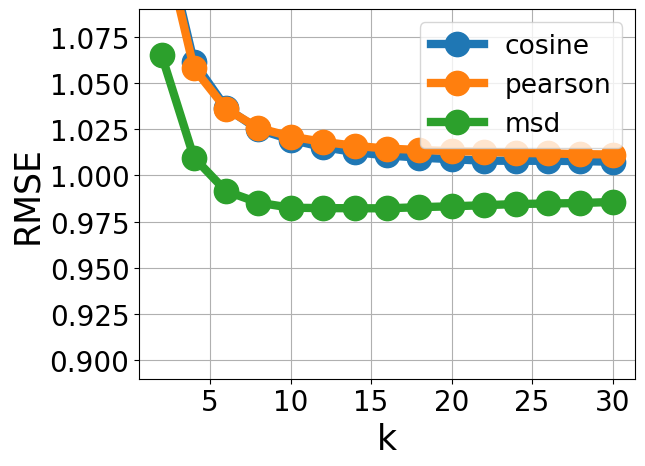

mejor RMSE: 0.9822015372439126, configuración de parámetros: {'k': 16, 'sim_options': {'name': 'msd', 'user_based': True}}


In [9]:
resultadosBasic = pd.DataFrame.from_dict(gsBasic.cv_results)
for simil in ['cosine', 'pearson', 'msd']:
    filtro = resultadosBasic['param_sim_options'].apply(lambda x: x['name'] == simil)
    df = resultadosBasic[filtro]
    plt.plot(df['param_k'], df['mean_test_rmse'], marker='.', label=simil, lw=6, ms=35)

# plt.style.use("ggplot")
plt.style.use('default')
plt.xlabel('k', fontsize=25)
plt.ylim(0.89,1.09)
plt.ylabel('RMSE', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.title('KNNBasic',fontsize=20)
plt.grid()
plt.legend(facecolor="white", fontsize=19)
plt.show()
print(f"mejor RMSE: {gsBasic.best_score['rmse']}, configuración de parámetros: {gsBasic.best_params['rmse']}")

Con la mejor configuración de hiperparámetros, se reentrena el modelo usando train+val al completo (full) y se evalúa sobre test.

In [10]:
# trainset = data_train.build_full_trainset() #objeto
trainset = datos.build_full_trainset() #objeto
modelo = KNNBasic(**gsBasic.best_params['rmse'])
modelo.fit(trainset)
# Evaluar sobre test
testset = list(test[['userId', 'movieId', 'rating']].itertuples(index=False, name=None))
predictions = modelo.test(testset)

Computing the msd similarity matrix...
Done computing similarity matrix.


In [11]:
accuracy.rmse(predictions)
accuracy.mae(predictions)

RMSE: 0.9856
MAE:  0.7498


np.float64(0.7498451965315494)

## KNNWithMeans
Igual que KNNBasic, pero corrigiendo el sesgo de cada usuario (o película): la predicción se calcula sobre las desviaciones respecto a la media, en lugar de sobre los ratings directamente. Se sigue el mismo procedimiento de grid search, gráfica y evaluación sobre test.

In [12]:
gsMeans = GridSearchCV(KNNWithMeans, param_grid, measures =['rmse','MAE'], cv=cv)
gsMeans.fit(datos)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearso

In [13]:
trainset = datos.build_full_trainset() #objeto
modelo = KNNWithMeans(**gsMeans.best_params['rmse'])
modelo.fit(trainset)
# Evaluar sobre test
testset = list(test[['userId', 'movieId', 'rating']].itertuples(index=False, name=None))
predictions = modelo.test(testset)

Computing the msd similarity matrix...
Done computing similarity matrix.


In [14]:
# Evaluar sobre test
accuracy.rmse(predictions)
accuracy.mae(predictions)

RMSE: 0.9419
MAE:  0.7196


np.float64(0.7196429098918549)

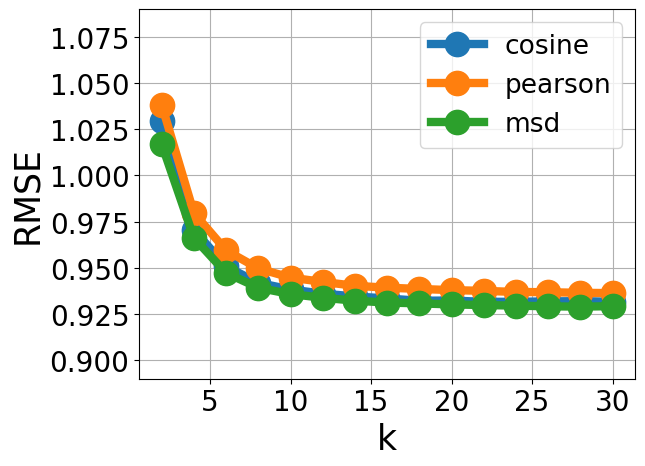

mejor RMSE: 0.9290115270140268, configuración de parámetros: {'k': 28, 'sim_options': {'name': 'msd', 'user_based': True}}


In [15]:
resultadosMeans = pd.DataFrame.from_dict(gsMeans.cv_results)
for simil in ['cosine', 'pearson', 'msd']:
    filtro = resultadosMeans['param_sim_options'].apply(lambda x: x['name'] == simil)
    df = resultadosMeans[filtro]
    plt.plot(df['param_k'], df['mean_test_rmse'], marker='.', label=simil, lw=6, ms=35)

# plt.style.use("ggplot")
plt.style.use('default')
plt.xlabel('k', fontsize=25)
plt.ylabel('RMSE', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(0.89,1.09)
# plt.title('KNNWithMeans')
plt.grid()
plt.legend(facecolor="white", fontsize=19)
plt.show()
print(f"mejor RMSE: {gsMeans.best_score['rmse']}, configuración de parámetros: {gsMeans.best_params['rmse']}")

## KNNBaseline
Igual que los anteriores, pero usando estimaciones baseline (calculadas con ALS) para modelar el sesgo de usuario y de película antes de aplicar KNN sobre los residuos. Se sigue el mismo procedimiento de grid search, gráfica y evaluación sobre test.

In [16]:
gsBaseline = GridSearchCV(KNNBaseline, param_grid, measures =['rmse','MAE'], cv=cv)
gsBaseline.fit(datos)

Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing th

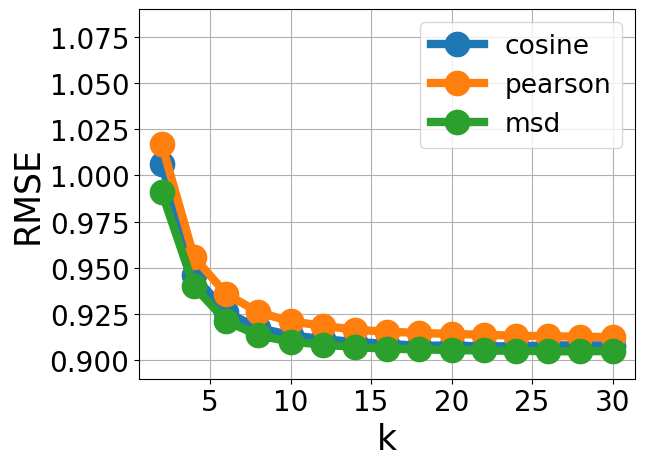

mejor RMSE: 0.9047883852880227, configuración de parámetros: {'k': 28, 'sim_options': {'name': 'msd', 'user_based': True}}


In [17]:
resultadosBaseline = pd.DataFrame.from_dict(gsBaseline.cv_results)
for simil in ['cosine', 'pearson', 'msd']:
    filtro = resultadosBaseline['param_sim_options'].apply(lambda x: x['name'] == simil)
    df = resultadosBaseline[filtro]
    plt.plot(df['param_k'], df['mean_test_rmse'], marker='.', label=simil, lw=6, ms=35)

# plt.style.use("ggplot")
plt.style.use('default')
plt.xlabel('k', fontsize=25)
plt.ylabel('RMSE', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(0.89,1.09)
# plt.title('KNNBaseline')
plt.grid()
plt.legend(fontsize=19) #facecolor="white"
plt.show()
print(f"mejor RMSE: {gsBaseline.best_score['rmse']}, configuración de parámetros: {gsBaseline.best_params['rmse']}")

In [18]:
trainset = datos.build_full_trainset() #objeto
modelo = KNNBaseline(**gsBaseline.best_params['rmse'])
modelo.fit(trainset)
# Evaluar sobre test
testset = list(test[['userId', 'movieId', 'rating']].itertuples(index=False, name=None))
predictions = modelo.test(testset)

Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.


In [19]:
# Evaluar sobre test
accuracy.rmse(predictions)
accuracy.mae(predictions)

RMSE: 0.9060
MAE:  0.6936


np.float64(0.6936262040370776)

## Resumen
Comparando el RMSE sobre test de los tres algoritmos, KNNBaseline (0.9060) obtiene mejor resultado que KNNWithMeans (0.9419) y KNNBasic (0.9856), gracias a modelar el sesgo de usuario y de película con las estimaciones baseline. En los tres casos, el RMSE es algo peor que en la variante item-based (KNNitem.ipynb).